In [2]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [9]:
import os
from pathlib import Path

dataset_path = "../data/dataset_nao"

true_labels = []
predictions = []
filenames = []

for true_label in os.listdir(dataset_path):
    class_dir = os.path.join(dataset_path, true_label)
    
    if not os.path.isdir(class_dir):
        continue
    
    for filename in os.listdir(class_dir):
        prediction = filename.split('_')[0]
        
        true_labels.append(int(true_label))
        predictions.append(int(prediction))
        filenames.append(filename)

df = pd.DataFrame({
    'true_label': true_labels,
    'prediction': predictions,
    'filename': filenames
})

df.head()

,true_label,prediction,filename
0,1,1,1_img_20260609_171354_264233.jpg
1,1,1,1_img_20260609_171401_463697.jpg
2,1,1,1_img_20260609_171402_123107.jpg
3,1,1,1_img_20260609_171402_783147.jpg
4,1,1,1_img_20260609_171403_383384.jpg


In [11]:
# Classification Report
print("=" * 60)
print("Reporte de clasificación")
print("=" * 60)
print(classification_report(df['true_label'], df['prediction']))

Reporte de clasificación
              precision    recall  f1-score   support

           1       1.00      0.91      0.95        11
           2       0.80      1.00      0.89         4

    accuracy                           0.93        15
   macro avg       0.90      0.95      0.92        15
weighted avg       0.95      0.93      0.94        15




CONFUSION MATRIX:
[[10  1]
 [ 0  4]]


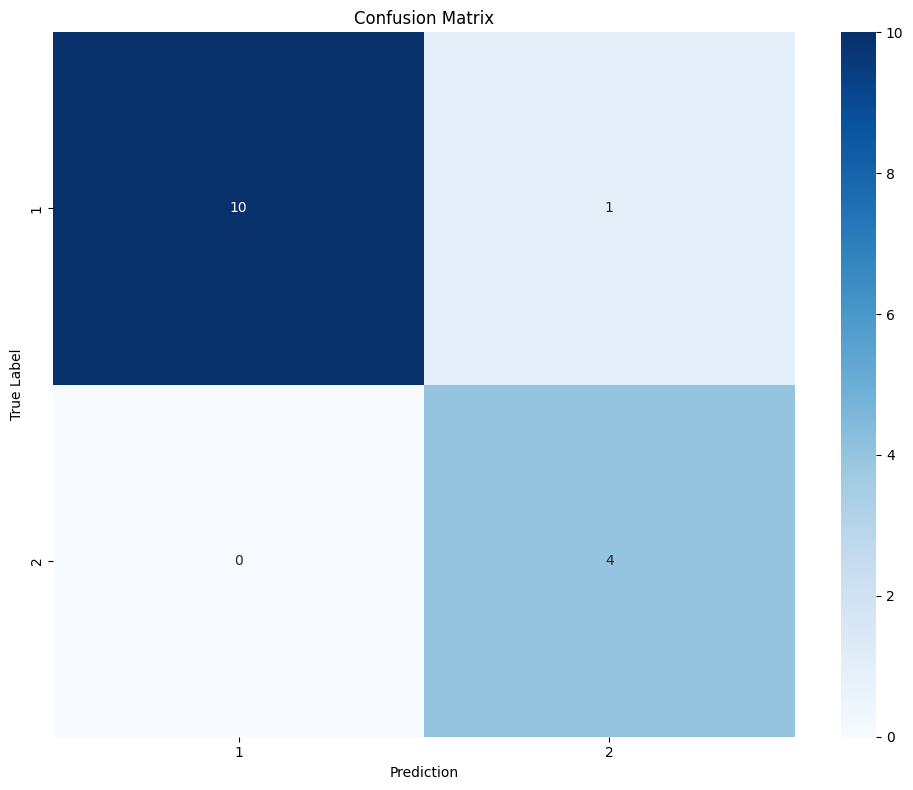

In [12]:
# Confusion Matrix
cm = confusion_matrix(df['true_label'], df['prediction'])

print("\nCONFUSION MATRIX:")
print(cm)

# Visualizar Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(df['true_label'].unique()),
            yticklabels=sorted(df['true_label'].unique()))
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Prediction')
plt.tight_layout()
plt.show()